<img src="https://devra.ai/analyst/notebook/5878/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">
  <div style="font-size:150%; color:#FEE100"><b>Healthy Diet and Calorie Intake Analysis</b></div>
  <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div>
</div>

Our data is as intriguing as it is nutritious. In our exploration today, we dive into the dietary and calorie consumption habits of different individuals, finding correlations and patterns that might explain their health statuses. If you enjoy this notebook and find the methods useful, consider upvoting it.

## Table of Contents

1. [Imports and Helper Functions](#Imports-and-Helper-Functions)
2. [Data Loading](#Data-Loading)
3. [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
4. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
5. [Predictive Modeling](#Predictive-Modeling)
6. [Conclusion and Future Work](#Conclusion-and-Future-Work)


In [1]:
# Imports and Helper Functions
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

# Helper function to resolve the data file path dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets')
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Set the style for seaborn plots
sns.set(style="whitegrid")

# For reproducibility
np.random.seed(42)


In [2]:
# Data Loading
try:
    # Attempt to resolve the file path dynamically
    file_path = resolve_data_file(file_name='healthy_diet_calorie_intake.csv', suffixes=['.csv'])
    
    # Read the CSV file as per the provided schema
    df = pd.read_csv(file_path, delimiter=',', encoding='ascii')
    
    # Display the first few rows of the dataframe
    print('Data loaded successfully. DataFrame shape:', df.shape)
except Exception as e:
    print('Error loading data:', e)
    raise

Data loaded successfully. DataFrame shape: (6000, 15)


In [3]:
# Data Cleaning and Preprocessing
# We first inspect the data types and missing values
print('Data Info:')
df.info()

# Check for missing values
missing_values = df.isnull().sum()
print('\nMissing values in each column:\n', missing_values)

# Ensure that categorical columns are of type string
categorical_cols = ['Person_ID', 'Gender', 'Activity_Level', 'Diet_Type', 'Health_Status']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('str')

# We can also check if any numeric columns need special handling
numeric_cols = ['Age', 'Height_cm', 'Weight_kg', 'BMI',
                'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
                'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']

print('\nDescriptive statistics for numeric columns:')
print(df[numeric_cols].describe())

# If dataset had date fields, here we would parse and convert them accordingly
# In this case, there is no explicit date column in the data provided.

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   object 
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-n

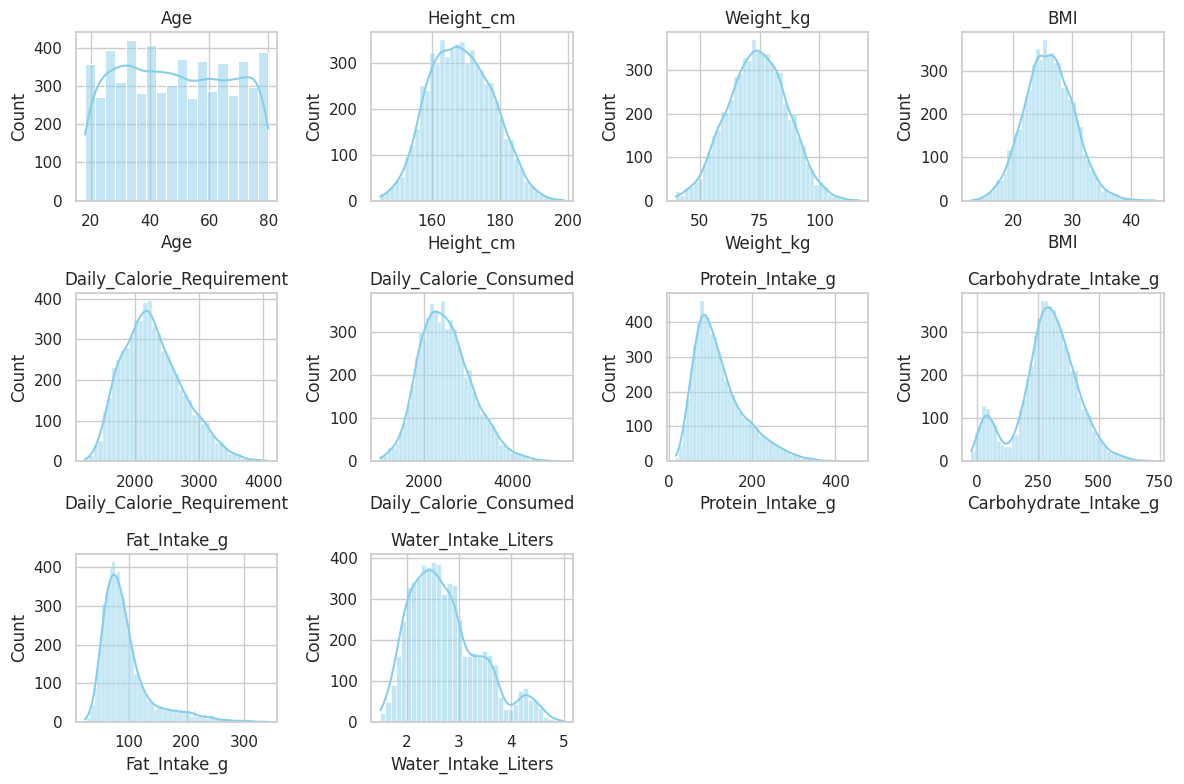

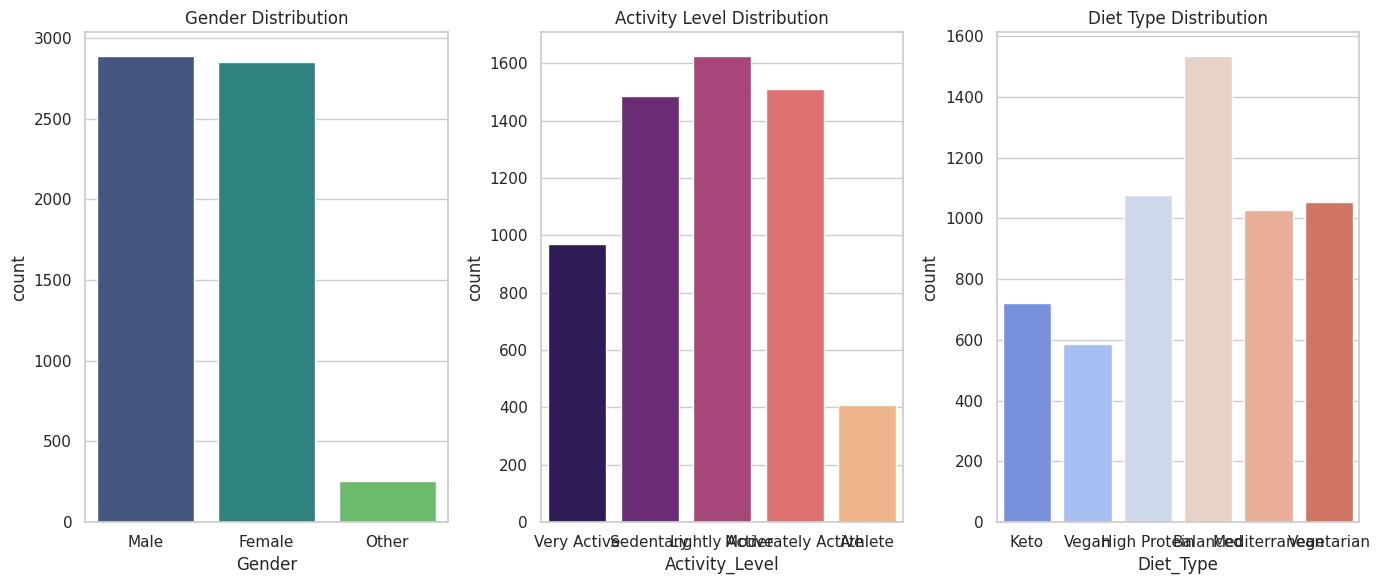

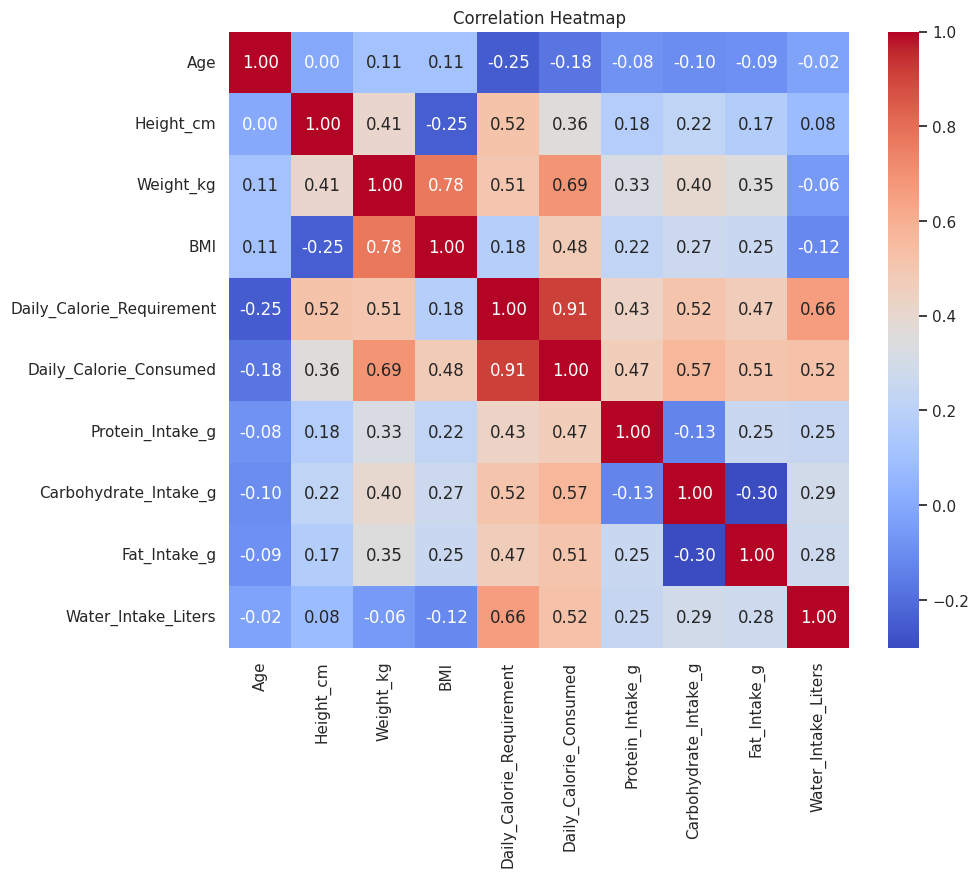

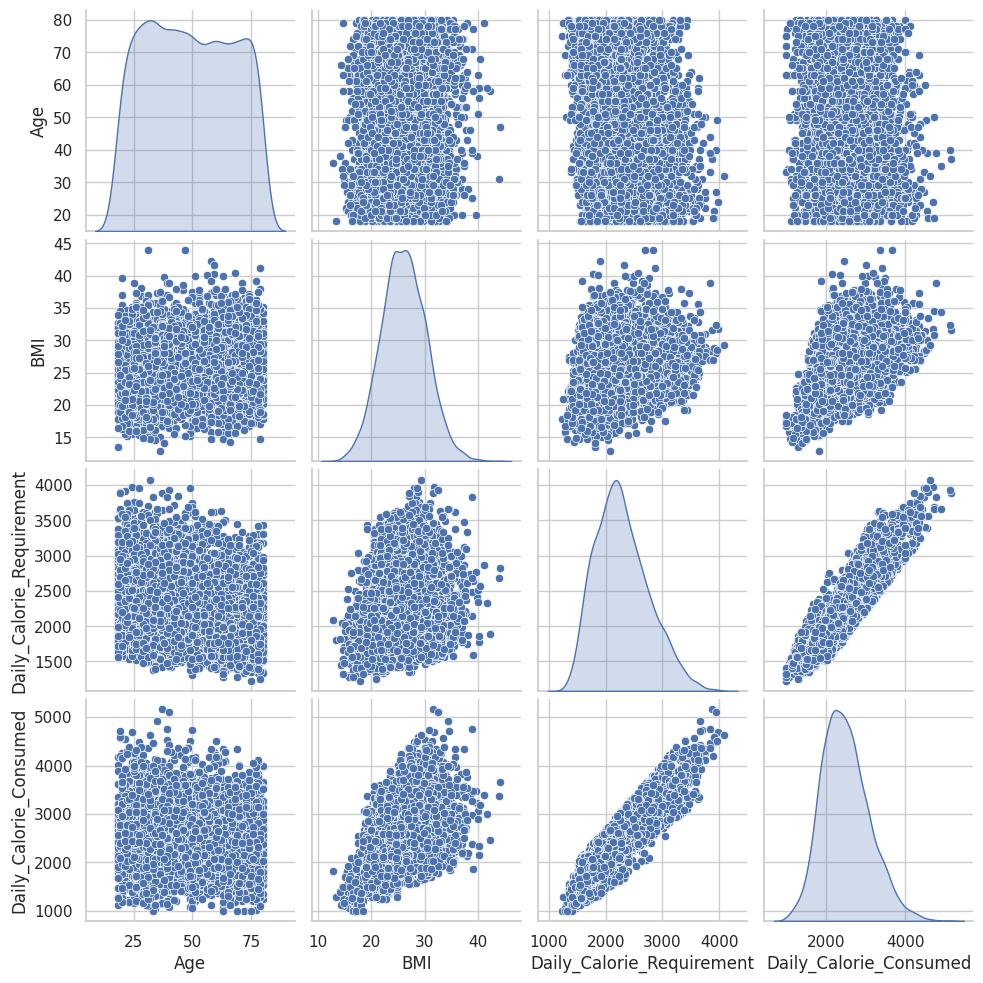

In [4]:
# Exploratory Data Analysis (EDA)
# We start with some summary visualizations to understand the distributions

# Plot histogram for numeric features
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

# Count plots for categorical features
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Gender Distribution')

plt.subplot(1, 3, 2)
sns.countplot(x='Activity_Level', data=df, palette='magma')
plt.title('Activity Level Distribution')

plt.subplot(1, 3, 3)
sns.countplot(x='Diet_Type', data=df, palette='coolwarm')
plt.title('Diet Type Distribution')

plt.tight_layout()
plt.show()

# If numeric data has four or more columns, we plot a heatmap for correlations
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

# Pairplot for a subset of key numeric features
cols_for_pairplot = ['Age', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed']
sns.pairplot(df[cols_for_pairplot].dropna(), diag_kind='kde')
plt.show()

Prediction Accuracy Score: 0.9916666666666667


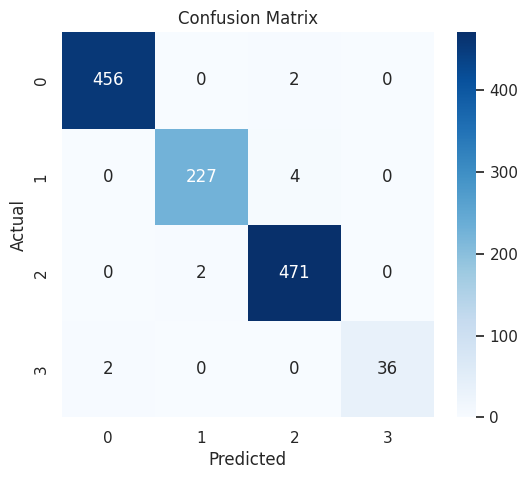

ROC curve not plotted because the classification is multi-class.


In [5]:
# Predictive Modeling
# Our goal here is to predict the Health_Status of individuals based on their dietary and lifestyle information.
# We will use a logistic regression classifier for simplicity. Note that this is a classification problem.

# Prepare the dataset
# We drop irrelevant columns such as Person_ID.
model_df = df.copy()
if 'Person_ID' in model_df.columns:
    model_df = model_df.drop('Person_ID', axis=1)

# For this predictive task, we treat 'Health_Status' as the target variable.
# We need to encode categorical variables. For simplicity, we'll perform one-hot encoding on categorical features (except the target).

target = 'Health_Status'
features = model_df.drop(columns=[target])

# Identify categorical features (exclude the target which we will encode separately if needed)
categorical_features = features.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical features
features_encoded = pd.get_dummies(features, columns=categorical_features, drop_first=True)

# For the target, we assume binary classification for simplicity
if model_df[target].nunique() == 2:
    # Map target to binary if not already
    target_mapping = {label: idx for idx, label in enumerate(model_df[target].unique())}
    y = model_df[target].map(target_mapping)
else:
    # For multi-class, we can still use Logistic Regression with multinomial option
    y = model_df[target]

X = features_encoded

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate prediction accuracy
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy Score:', acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# If this is a binary classification problem, plot the ROC curve
if len(np.unique(y)) == 2:
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()
else:
    print('ROC curve not plotted because the classification is multi-class.')

# A note on error handling: if you encounter data type conversion issues, especially with categorical encoding, 
# ensure that the data is cleaned and the proper type conversions are applied. This method prevents many common errors.

# Conclusion and Future Work

Our exploration of the healthy diet and calorie intake dataset has uncovered interesting trends in nutritional metrics and lifestyles. In this notebook, we performed data cleaning, exploratory visualizations, and even built a predictive model to classify health status. While the logistic regression model provided a baseline of prediction accuracy, future work could consider more advanced models (such as tree-based methods) or even ensemble methods. Detailed feature engineering and hyperparameter optimization may also yield improved performance.

If you found this notebook useful, please consider upvoting it.